## Functions

In [1]:
#import relevant libraries
import os
from scipy import stats
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap
import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import osar 

#NOTE: SUPPRESSES WARNINGS!

import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

print(osar.__version__)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 22.23it/s]


Numba compilation complete!
0.23.7


In [ ]:
# basegenotype = "R58"
# responder = "ACR"
# wt = "w1118"
# transgenic = basegenotype + " x " + responder

officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp
filedate = "20250311"

filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\2025collection\\"
filedirectory_Climbing = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Climbing_New\\Compilation with delta\\2025meandiffcollection\\"
filesavedir = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Totalosarclimbing\\images\\"

In [3]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

## Function

In [4]:
def twolightdabest(di, names, parameter, light):
    
    if light == 'Half' or light == 'Full':
        dfi = di[(di['light_intensity']==light)].reset_index(drop=True)
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['status'] == 'Offspring')].reset_index(drop=True)
        filter2 = dfi[(dfi['status'] == 'Sibling')].reset_index(drop=True)
                
        dfrr[names + " Cntrl" ] = filter2[parameter]
        dfrr[names + " " + light] = filter1[parameter]
       
        l = dfrr.columns.tolist()
        titlelst = list(zip(l,l[1:]))[::2]  
        test = dabest.load(dfrr, idx=titlelst)    
        
    if light == 'Both':
        
        df_half = di[(di['light_intensity']=="Half")].reset_index(drop=True)
        dfrr = pd.DataFrame()
        filter1_half = df_half[(df_half['status'] == 'Offspring')].reset_index(drop=True)
        filter2_half = df_half[(df_half['status'] == 'Sibling')].reset_index(drop=True)
        
        df_full = di[(di['light_intensity']=="Full")].reset_index(drop=True)
        filter1_full = df_full[(df_full['status'] == 'Offspring')].reset_index(drop=True)
        filter2_full = df_full[(df_full['status'] == 'Sibling')].reset_index(drop=True)
                
        dfrr["Cntrl_Half"] = filter2_half[parameter]
        dfrr[ "Half"] = filter1_half[parameter]
        dfrr["Cntrl_Full" ] = filter2_full[parameter]
        dfrr["Full"] = filter1_full[parameter]
        l = dfrr.columns.tolist()
        titlelst = list(zip(l,l[1:]))[::2]  
        test = dabest.load(dfrr, idx=titlelst)    
    
    return test

def find_number(df, lookup_value, genre):
    lobe_values = []
    for _, row in df.iterrows():
        # Splitting the 'MBON' values and removing any potential whitespace
        mbon_values = [x.strip() for x in row['MBON names'].split(',')]
        if lookup_value in mbon_values:
            lobe_values.append(row[genre])
            
    lobelobe = list(set(lobe_values))
    return ', '.join(lobelobe)

def MBONnamefile(MBONList, pathfile):
    #reading mbonlist file

    #MBONFILEDIRECTORY: specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Climbing_New\\"
    directorynew = os.path.dirname(os.path.dirname(pathfile)) #goes up one directory
    fileinnewdirc = os.listdir(directorynew)

    for file_no2 in fileinnewdirc:
        if ".csv" in file_no2:
            ff = os.path.join(directorynew, file_no2)
            csvfile = pd.read_csv(ff)

    csvfile = csvfile.astype('string')

    for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
        csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

    lobelocation = pd.DataFrame()

    for m in MBONList:
        lobeloc = pd.DataFrame()
        lobeloc['MBON'] = [m]
        loclst = find_number(csvfile, m, "Lobe")
        mbonlst = find_number(csvfile, m, "MBON number").strip()
        ntlst = find_number(csvfile, m, "Neurotransmitter")
        lobeloc['Lobe_location'] = [loclst]
        lobeloc['MBON number'] = [mbonlst]
        lobeloc['Neurotransmitter'] = [ntlst]
        
        lobelocation = pd.concat([lobelocation, lobeloc])

    lobelocation = lobelocation.reset_index(drop=True)
    return lobelocation

def matchingdfs (df, matchingset):
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = df[(df['MBON'] == n)]
        newdf_a = pd.concat([newdf_a, df_a]).reset_index(drop=True)
    return newdf_a

import textwrap

def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)
    
def matchinglobesets(dfreg_a, lobelocation):
    lobelocation_a = lobelocation.sort_values(by=['MBON']).reset_index(drop=True)
    dfreg_a_withloc = dfreg_a.sort_values(by=['MBON']).reset_index(drop=True)
    matchinglobereg = list(set(lobelocation_a['MBON']) & set(dfreg_a_withloc['MBON']))

    dflobe_reg = matchingdfs(lobelocation_a, matchinglobereg).sort_values(by=['MBON']).reset_index(drop=True)

    dfreg_a_withloc['Lobe_location'] = dflobe_reg['Lobe_location']
    dfreg_a_withloc['MBON number'] = dflobe_reg['MBON number']
    dfreg_a_withloc['Neurotransmitter'] = dflobe_reg['Neurotransmitter']

    return dfreg_a_withloc

def matchingcomp(dfreg_Cr2, osar_multiplot_cr2):
    matchingset = list(set(dfreg_Cr2['MBON']) & set(osar_multiplot_cr2['MBON']))
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = dfreg_Cr2[(dfreg_Cr2['MBON'] == n)]
        df_b = pd.merge(df_a, osar_multiplot_cr2, on = "MBON" )
        newdf_a = pd.concat([newdf_a, df_b]).reset_index(drop=True)
        
    return newdf_a

# Comparison models

## Direct comparison (Log vs Non Log)

In [18]:
def multiresponder_osar(df2, responder):    
    from functools import reduce
    
    dfi=df2[(df2['light_intensity']=='Full')].reset_index(drop=True)  #Full light only
    dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
    dfi.rename(columns={'driver': 'MBON'}, inplace = True)
    
    basegenotype = dfi['MBON'].unique()
    
    dfpi, sortedlist, dabestlist = chartplottingdabest(dfi, basegenotype, 'pi_smoothed_Pattern 01')
    dfspeed= chartplottingdabest(dfi, basegenotype, 'log2_speed_ratio_Pattern 01')[0]
    dfpace = chartplottingdabest(dfi, basegenotype, 'log2_pace_ratio_Pattern 01')[0]

    piplot = dabest.load(dfpi, idx=dabestlist)
    spplot = dabest.load(dfspeed, idx=dabestlist)
    pcplot = dabest.load(dfpace, idx=dabestlist) 

    pitable = pd.DataFrame({'MBON': piplot.hedges_g.statistical_tests['test'],'Δ PI': piplot.hedges_g.statistical_tests['difference']})
    sptable = pd.DataFrame({'MBON': spplot.hedges_g.statistical_tests['test'],'Δ Log2 Speed Ratio': spplot.hedges_g.statistical_tests['difference']})
    pctable = pd.DataFrame({'MBON': pcplot.hedges_g.statistical_tests['test'],'Δ Log2 Pace Ratio': pcplot.hedges_g.statistical_tests['difference']})
    tabletotallst = [pitable, sptable, pctable]

    tabletotal = reduce(lambda left, right: pd.merge(left, right, on =['MBON'], how = "outer"), tabletotallst)

    tabletotal['responder'] = responder
    
    return tabletotal

def chartplottingdabest(dfi, basegenotype, parameter):
    
    dfr1 = pd.DataFrame()
    for names in basegenotype:
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
        filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

        dfrr[names + " Cntrl" ] = filter2[parameter]
        dfrr[names] = filter1[parameter]
        dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfr1.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    
    test = dabest.load(dfr1, idx=titlelst)    
    tab = pd.concat([test.hedges_g.results['test'], test.hedges_g.results['difference']], axis = 1)
    
    arrangedsorting = tab.sort_values(by=['difference'], ascending = True).reset_index(drop=True)

    newlist = []
    for n in arrangedsorting['test']:
        newlist.append((n +" Cntrl", n))

    return dfr1, arrangedsorting['test'], newlist


In [ ]:
#lobe location

newfile2 = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Climbing_New\\Compilation with delta\\2025deltagcollection\\"
files2 = os.listdir(newfile2)

MBONList = []666
for yy in files2:
    MBONList.append(yy.split(" ")[0])

MBONList = list(set(MBONList))

lobelocation = MBONnamefile(MBONList, specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Climbing_New\\")

In [20]:
from collections import Counter
counts = Counter([item.split(' ')[0] for item in files2])
matchingsets = [value for value, count in counts.items() if count > 1]
matchinglst = [v for v in files2 if any(short_name in v for short_name in matchingsets)]
dfreg_ACR = pd.DataFrame()
dfreg_Chrimson2 = pd.DataFrame()

for f in matchinglst:
    if "Chrimson2" in f:
        temp = pd.read_csv(newfile2 + f, index_col=0)
        temp = temp.loc[:, ~temp.columns.str.endswith('_bootstrap')].drop_duplicates()
        dfreg_Chrimson2 = pd.concat([dfreg_Chrimson2, temp], axis = 0)
    if "ACR" in f:
        temp = pd.read_csv(newfile2 + f, index_col=0)
        temp = temp.loc[:, ~temp.columns.str.endswith('_bootstrap')].drop_duplicates()
        dfreg_ACR = pd.concat([dfreg_ACR, temp], axis = 0)
        

dfreg_Chrimson2 = dfreg_Chrimson2.reset_index(drop=False)
dfreg_Chrimson2['genotypeandresponder'] = dfreg_Chrimson2['MBON'] + '_Chrimson2'

dfreg_ACR = dfreg_ACR.reset_index(drop=False)
dfreg_ACR['genotypeandresponder'] = dfreg_ACR['MBON'] + '_ACR'



In [ ]:
#osar stuff
root = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\"
filepathACR = root + filedate + "_ACR_totalcompilation.csv"
filepathCR2 = root + filedate + "_Chrimson2_totalcompilation.csv"

dffileACR= pd.read_csv(filepathACR, index_col=0)
dffileCR2= pd.read_csv(filepathCR2, index_col=0)

dffACR = multiresponder_osar(dffileACR, "ACR")
dffCR2 = multiresponder_osar(dffileCR2, "Chrimson2")


dfmultiresponderosar = pd.concat([dffACR, dffCR2]).reset_index(drop=True)
dfmultiresponderosar['genotypeandresponder'] = dfmultiresponderosar['MBON'] + "_" + dfmultiresponderosar['responder']

In [21]:
dfregtotal= pd.concat([dfreg_ACR, dfreg_Chrimson2], axis = 0).reset_index(drop=True)
dfosartotal = dfregtotal.loc[:,['genotypeandresponder', 'bspeed_deltag', 'speed_deltag']]

dfmix = dfmultiresponderosar.merge(dfosartotal, on="genotypeandresponder", how= "inner")
#dfmix = dfmix.drop(['responder'], axis = 1)
dfmix = dfmix.sort_values(by = ["genotypeandresponder"])

osarmatchdf = dfmix[~dfmix['MBON'].isin(['R58', 'Th-Gal4'])]

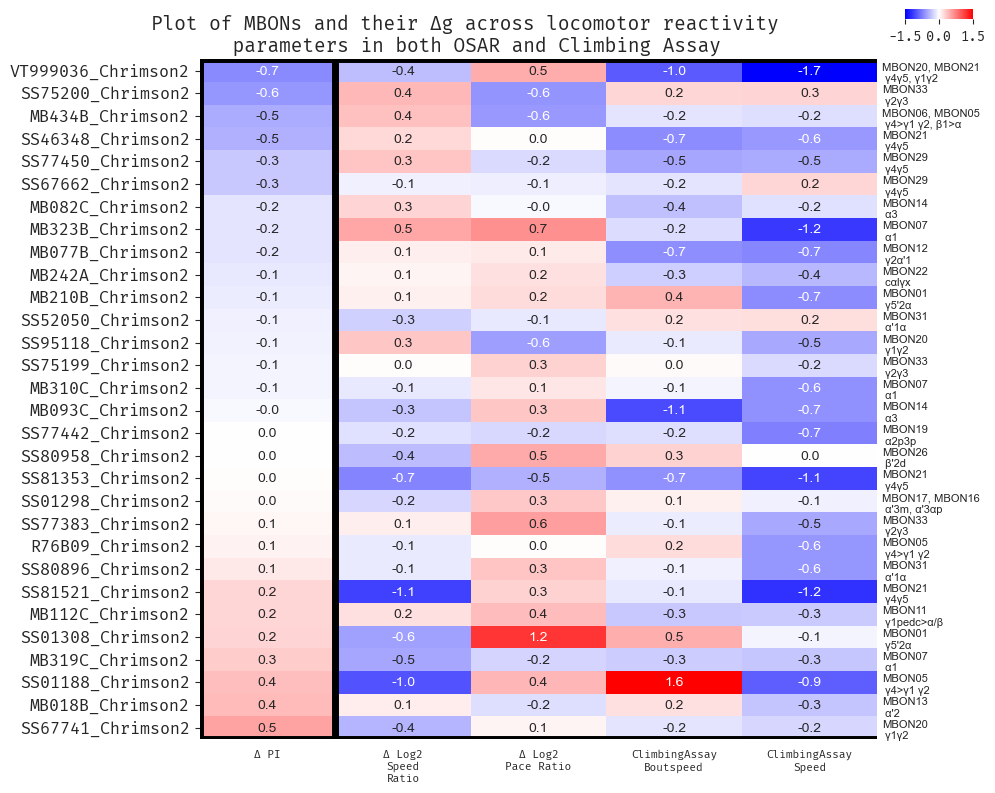

In [ ]:
#total mbon list including ACR and chrimson2
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
responder = "Chrimson2"

plt.rcParams["font.family"] = "Inter"

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = osarmatchdf[osarmatchdf['responder']=="Chrimson2"].sort_values(by = "Δ PI", ascending=True).reset_index(drop=True)

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = osarmatchdf[osarmatchdf['responder']=="ACR"].sort_values(by = "Δ PI", ascending=True).reset_index(drop=True)

df00 = df_specificmbon.set_index(['genotypeandresponder'])
df00.columns = df00.columns.str.replace('_deltag', '')    

fig1, ax3 = plt.subplots(figsize=(10,8))     
#adding extra axes label
lobloclst = []
mbonloclst = []
df500 = df00.copy()
for n in df00['MBON']:    
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df500['Lobe'] = lobloclst
df500['Name'] = mbonloclst

df00 = df00.drop(['MBON', 'responder'], axis =1)
#labelling of MBON number and location but ONLY ifc comparing ACR and CHRIMSON2

# newdf500 = pd.DataFrame()
# naming = df500['Name'].iloc[::2].to_frame().rename(columns = {"Name": ""})
# lobing = df500['Lobe'].iloc[1::2].to_frame().rename(columns = {"Lobe": ""})
# newlabel =(naming.values + "\n " + lobing.values).tolist()
# newdf500['Merge'] = newlabel

#single responder
newdf500 = pd.DataFrame()
naming = df500['Name'].to_frame().rename(columns = {"Name": ""})
lobing = df500['Lobe'].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf500['Merge'] = newlabel

#new labels for heatmap
xticklabeldf = df00.rename(columns={'bspeed': 'ClimbingAssay Boutspeed', 'speed': 'ClimbingAssay Speed'})

xticklabellist = xticklabeldf.columns.tolist()

#colorbar
cax = inset_axes(ax3,
                 width="10%",  # width: 40% of parent_bbox width
                 height="1.5%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.1, 1.1, 1, 1),
                 bbox_transform=ax3.transAxes,
                 borderpad=-2,
                 )

sns.set_style("whitegrid", {'axes.grid' : False})           
j7 = sns.heatmap(df00, ax = ax3, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap='bwr', linewidths=0.0, edgecolor = "none",  xticklabels=xticklabellist, yticklabels=True
                 , clip_on=False, cbar_ax=cax, cbar_kws = dict(orientation = "horizontal", ticks = [-1.5, 0 ,1.5]), annot_kws={"size": 10}) #use_gridspec=False,location="bottom", shrink = 0.25, pad=0.01 #cbar_kws = dict(orientation = "vertical")
j7.set_ylabel('')
j7.set_yticklabels(j7.get_yticklabels(), va='center', rotation = 0, fontsize = 12)
j7.set_xticklabels(j7.get_xticklabels(), rotation = 0, fontsize = 8)
wrap_labels(j7, 10)

# Drawing the frame for subplot 1
j7.axhline(y = 0, color = 'k', linewidth = 5) 
j7.axhline(y = len(df00), color = 'k', linewidth = 5) 
j7.axvline(x = 0, color = 'k', linewidth = 5) 
j7.axvline(x = 1, color = 'k', linewidth = 5) 

#secondary axes
j8 = j7.twinx()
j8.set_ylim([0,j7.get_ylim()[0]])
j8.set_yticks(j7.get_yticks())
j8.tick_params(length=0)

#y labels for mbon lobes and naming
labellinglist = newdf500['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    #labelledlist.extend(("", n[0]))  #inserts blank space after every list name
    labelledlist.extend(n)     #either or
    
#j8.set_yticklabels(newdf500['Merge'].iloc[::-1], fontsize=10)
j8.set_yticklabels(labelledlist, fontsize=8)
j8.spines['top'].set_visible(False)
j8.spines['right'].set_visible(False)
j8.spines['bottom'].set_visible(False)
j8.spines['left'].set_visible(False)


j7.set_title('Plot of MBONs and their Δg across locomotor reactivity \n parameters in both OSAR and Climbing Assay', x=0.4, weight='bold', fontsize =14)

fig1.tight_layout()

#plt.savefig(openPath + "images\\" + date + "_ACRChrimson2_deltagheatmapwithlobelocations.png", dpi = 1200)

# Climbing to Log speed ratio (single and multiplot)

## Basic functions to run

In [5]:
def multiresponder_osar(df2, responder):    
    from functools import reduce
    
    dfi=df2[(df2['light_intensity']=='Full')].reset_index(drop=True)  #Full light only
    dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
    dfi.rename(columns={'driver': 'MBON'}, inplace = True)
    
    basegenotype = dfi['MBON'].unique()
    
    dfpi, sortedlist, dabestlist = chartplottingdabest(dfi, basegenotype, 'pi_smoothed_Pattern 01')
    dfspeed= chartplottingdabest(dfi, basegenotype, 'log2_speed_ratio_Pattern 01')[0]
    dfpace = chartplottingdabest(dfi, basegenotype, 'log2_pace_ratio_Pattern 01')[0]

    piplot = dabest.load(dfpi, idx=dabestlist)
    spplot = dabest.load(dfspeed, idx=dabestlist)
    pcplot = dabest.load(dfpace, idx=dabestlist) 

    pitable = pd.DataFrame({'MBON': piplot.hedges_g.statistical_tests['test'],'Δ PI': piplot.hedges_g.statistical_tests['difference']})
    sptable = pd.DataFrame({'MBON': spplot.hedges_g.statistical_tests['test'],'Δ Log2 Speed Ratio': spplot.hedges_g.statistical_tests['difference']})
    pctable = pd.DataFrame({'MBON': pcplot.hedges_g.statistical_tests['test'],'Δ Log2 Pace Ratio': pcplot.hedges_g.statistical_tests['difference']})
    tabletotallst = [pitable, sptable, pctable]

    tabletotal = reduce(lambda left, right: pd.merge(left, right, on =['MBON'], how = "outer"), tabletotallst)

    tabletotal['responder'] = responder
    
    return tabletotal

def chartplottingdabest(dfi, basegenotype, parameter):
    
    dfr1 = pd.DataFrame()
    for names in basegenotype:
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
        filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

        dfrr[names + " Cntrl" ] = filter2[parameter]
        dfrr[names] = filter1[parameter]
        dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfr1.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    
    test = dabest.load(dfr1, idx=titlelst)    
    tab = pd.concat([test.hedges_g.results['test'], test.hedges_g.results['difference']], axis = 1)
    
    arrangedsorting = tab.sort_values(by=['difference'], ascending = True).reset_index(drop=True)

    newlist = []
    for n in arrangedsorting['test']:
        newlist.append((n +" Cntrl", n))

    return dfr1, arrangedsorting['test'], newlist


In [6]:
newfile2 = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Climbing_New\\Compilation with delta\\2025climbingtoosarcomp\\"
files2 = os.listdir(newfile2)


#mbon locations
MBONList = []
for yy in files2:
    MBONList.append(yy.split(" ")[0])

MBONList = list(set(MBONList))

lobelocation = MBONnamefile(MBONList, specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Climbing_New\\")

In [7]:
#climbing stuff
from collections import Counter
counts = Counter([item.split(' ')[0] for item in files2])
matchingsets = [value for value, count in counts.items() if count > 1]
matchinglst = [v for v in files2 if any(short_name in v for short_name in matchingsets)]
dfreg_ACR = pd.DataFrame()
dfreg_Chrimson2 = pd.DataFrame()

for f in matchinglst:
    if "Chrimson2" in f:
        temp = pd.read_csv(newfile2 + f, index_col=0)
        temp = temp.loc[:, ~temp.columns.str.endswith('_bootstrap')].drop_duplicates()
        dfreg_Chrimson2 = pd.concat([dfreg_Chrimson2, temp], axis = 0)
    if "ACR" in f:
        temp = pd.read_csv(newfile2 + f, index_col=0)
        temp = temp.loc[:, ~temp.columns.str.endswith('_bootstrap')].drop_duplicates()
        dfreg_ACR = pd.concat([dfreg_ACR, temp], axis = 0)
        

dfreg_Chrimson2 = dfreg_Chrimson2.reset_index(drop=False)
dfreg_Chrimson2['genotypeandresponder'] = dfreg_Chrimson2['MBON'] + '_Chrimson2'

dfreg_ACR = dfreg_ACR.reset_index(drop=False)
dfreg_ACR['genotypeandresponder'] = dfreg_ACR['MBON'] + '_ACR'



In [ ]:
#osar stuff
root = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\"
filepathACR = root + filedate + "_ACR_totalcompilation.csv"
filepathCR2 = root + filedate + "_Chrimson2_totalcompilation.csv"

dffileACR= pd.read_csv(filepathACR, index_col=0)
dffileCR2= pd.read_csv(filepathCR2, index_col=0)

dffACR = multiresponder_osar(dffileACR, "ACR")
dffCR2 = multiresponder_osar(dffileCR2, "Chrimson2")


dfmultiresponderosar = pd.concat([dffACR, dffCR2]).reset_index(drop=True)
dfmultiresponderosar['genotypeandresponder'] = dfmultiresponderosar['MBON'] + "_" + dfmultiresponderosar['responder']

In [9]:
dfregtotal= pd.concat([dfreg_ACR, dfreg_Chrimson2], axis = 0).reset_index(drop=True)
dfosartotal = dfregtotal.loc[:,['genotypeandresponder', 'bspeed_hedgesg', 'speed_hedgesg']]

dfmix = dfmultiresponderosar.merge(dfosartotal, on="genotypeandresponder", how= "inner")
#dfmix = dfmix.drop(['responder'], axis = 1)
dfmix = dfmix.sort_values(by = ["genotypeandresponder"])

osarmatchdf = dfmix[~dfmix['MBON'].isin(['R58', 'Th-Gal4'])]

In [14]:
# to generate excel file only
osarexcel = osarmatchdf.copy()
osarexcel = osarexcel.rename(columns={'Δ PI': 'Δ PI_OSAR', 'Δ Log2 Speed Ratio': 'Δ Log2 Speed Ratio_OSAR', 'Δ Log2 Pace Ratio': 'Δ Log2 Bout Speed Ratio_OSAR'
                             , 'bspeed_hedgesg': 'Δ Log2 Bout Speed Ratio_Climbing', 'speed_hedgesg': 'Δ Log2 Speed Ratio_Climbing'}).reset_index(drop=True)
osarexcel.to_excel(homecomp + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\OSAR and Climbing_delta Log2SR and delta Log2BSR comparison.xlsx", index = False)

## Heatmap

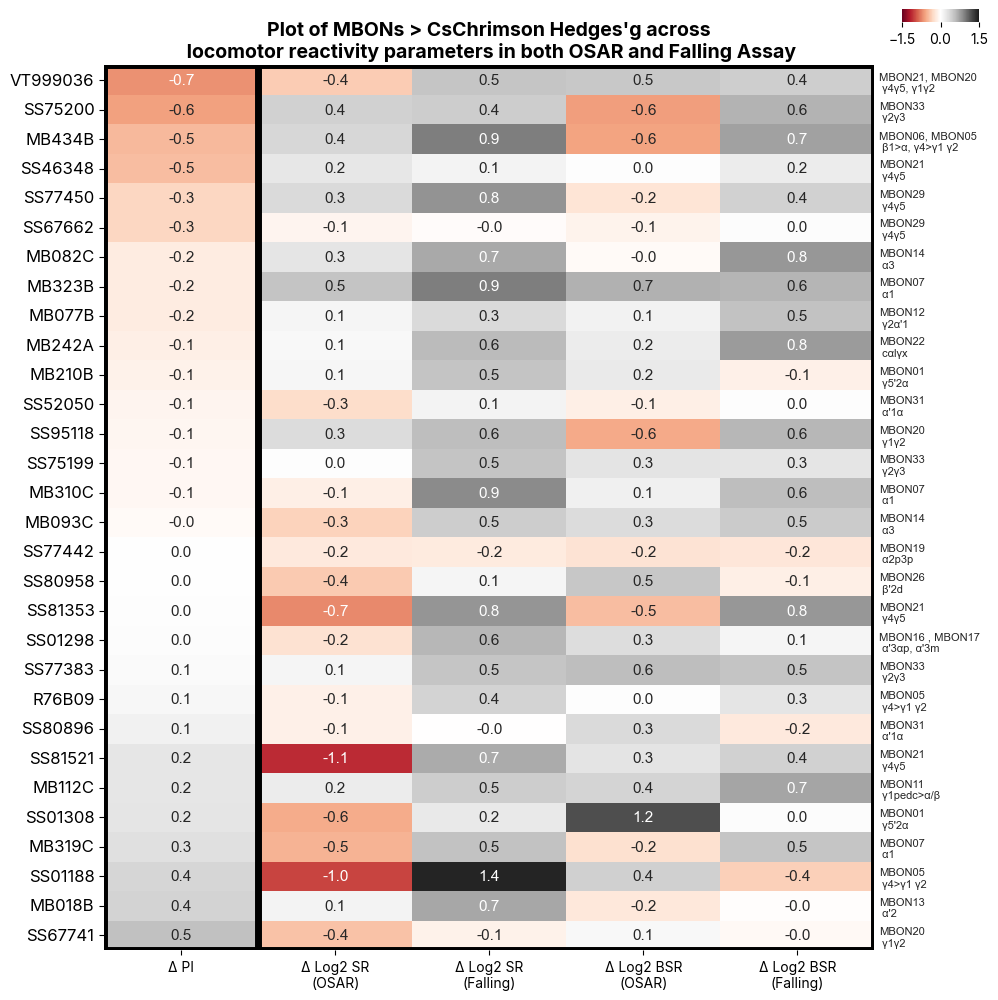

In [11]:
#total mbon list including ACR and chrimson2
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
responder = "Chrimson2"

plt.rcParams["font.family"] = "Inter"

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = osarmatchdf[osarmatchdf['responder']=="Chrimson2"].sort_values(by = "Δ PI", ascending=True).reset_index(drop=True)
    colormap = 'RdGy'

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = osarmatchdf[osarmatchdf['responder']=="ACR"].sort_values(by = "Δ PI", ascending=True).reset_index(drop=True)
    colormap = 'BrBG'

df00 = df_specificmbon.set_index(['genotypeandresponder'])
df00.columns = df00.columns.str.replace('_deltag', '')    

fig1, ax3 = plt.subplots(figsize=(10,10))     
#adding extra axes label
lobloclst = []
mbonloclst = []
df500 = df00.copy()
for n in df00['MBON']:    
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df500['Lobe'] = lobloclst
df500['Name'] = mbonloclst

df00 = df00.drop(['MBON', 'responder'], axis =1)
#labelling of MBON number and location but ONLY ifc comparing ACR and CHRIMSON2

# newdf500 = pd.DataFrame()
# naming = df500['Name'].iloc[::2].to_frame().rename(columns = {"Name": ""})
# lobing = df500['Lobe'].iloc[1::2].to_frame().rename(columns = {"Lobe": ""})
# newlabel =(naming.values + "\n " + lobing.values).tolist()
# newdf500['Merge'] = newlabel

#single responder
newdf500 = pd.DataFrame()
naming = df500['Name'].to_frame().rename(columns = {"Name": ""})
lobing = df500['Lobe'].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf500['Merge'] = newlabel

#new labels for heatmap

df00 = df00[['Δ PI', 'Δ Log2 Speed Ratio', 'speed_hedgesg', 'Δ Log2 Pace Ratio', 'bspeed_hedgesg']]
xticklabeldf = df00.rename(columns={'Δ Log2 Speed Ratio': "Δ Log2 SR (OSAR)" , 'Δ Log2 Pace Ratio': "Δ Log2 BSR (OSAR)" ,'bspeed_hedgesg': 'Δ Log2 BSR (Climbing)', 'speed_hedgesg': 'Δ Log2 SR (Climbing)'})
xticklabellist = xticklabeldf.columns.tolist()
yticklabels = [label.split("_")[0] for label in df00.index]

#colorbar
cax = inset_axes(ax3,
                 width="10%",  # width: 40% of parent_bbox width
                 height="1.5%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.1, 1.08, 1, 1),
                 bbox_transform=ax3.transAxes,
                 borderpad=-2,
                 )

sns.set_style("whitegrid", {'axes.grid' : False})           
j7 = sns.heatmap(df00, ax = ax3, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap=colormap, linewidths=0.0, edgecolor = "none",  xticklabels=xticklabellist, yticklabels=yticklabels
                 , clip_on=False, cbar_ax=cax, cbar_kws = dict(orientation = "horizontal", ticks = [-1.5, 0 ,1.5]), annot_kws={"size": 11}) #use_gridspec=False,location="bottom", shrink = 0.25, pad=0.01 #cbar_kws = dict(orientation = "vertical")
j7.set_ylabel('')
j7.set_yticklabels(j7.get_yticklabels(), va='center', rotation = 0, fontsize = 12)
j7.set_xticklabels(j7.get_xticklabels(), rotation = 0, fontsize = 10)
wrap_labels(j7, 10)

# Drawing the frame for subplot 1
j7.axhline(y = 0, color = 'k', linewidth = 5) 
j7.axhline(y = len(df00), color = 'k', linewidth = 5) 
j7.axvline(x = 0, color = 'k', linewidth = 5) 
j7.axvline(x = 1, color = 'k', linewidth = 5) 
j7.axvline(x = len(df00.columns), color = 'k', linewidth = 5) 

#secondary axes
j8 = j7.twinx()
j8.set_ylim([0,j7.get_ylim()[0]])
j8.set_yticks(j7.get_yticks())
j8.tick_params(length=0)

#y labels for mbon lobes and naming
labellinglist = newdf500['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    #labelledlist.extend(("", n[0]))  #inserts blank space after every list name
    labelledlist.extend(n)     #either or
    
#j8.set_yticklabels(newdf500['Merge'].iloc[::-1], fontsize=10)
j8.set_yticklabels(labelledlist, fontsize=8)
j8.spines['top'].set_visible(False)
j8.spines['right'].set_visible(False)
j8.spines['bottom'].set_visible(False)
j8.spines['left'].set_visible(False)


j7.set_title("Plot of MBONs > " + responderrename + " Hedges'g across\n locomotor reactivity parameters in both OSAR and Climbing Assay", x=0.5, weight='bold', fontsize =14)

fig1.tight_layout()

plt.savefig(filesavedir + date + "_"+ responder+"_hedgesgheatmap.png", dpi = 1200)
plt.savefig(filesavedir + date + "_"+ responder +"_hedgesgheatmap.svg")

## Lin reg

In [12]:
def omission(df):
    tempdff = df[df['MBON'] != 'VT999036'].reset_index(drop=True) #removing outlier
    dfomitted = tempdff[~((tempdff['Δ PI'].abs() < 0.2) & (tempdff['Δ Log2 Speed Ratio'].abs() < 0.2))]
   
    return dfomitted.reset_index(drop=True)

In [15]:
responder = "Chrimson2"

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = osarmatchdf[osarmatchdf['responder']=="Chrimson2"].sort_values(by = "Δ PI", ascending=True).reset_index(drop=True)
    colorline = "#ff0000"

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = osarmatchdf[osarmatchdf['responder']=="ACR"].sort_values(by = "Δ PI", ascending=True).reset_index(drop=True)
    colorline = "#14962c"

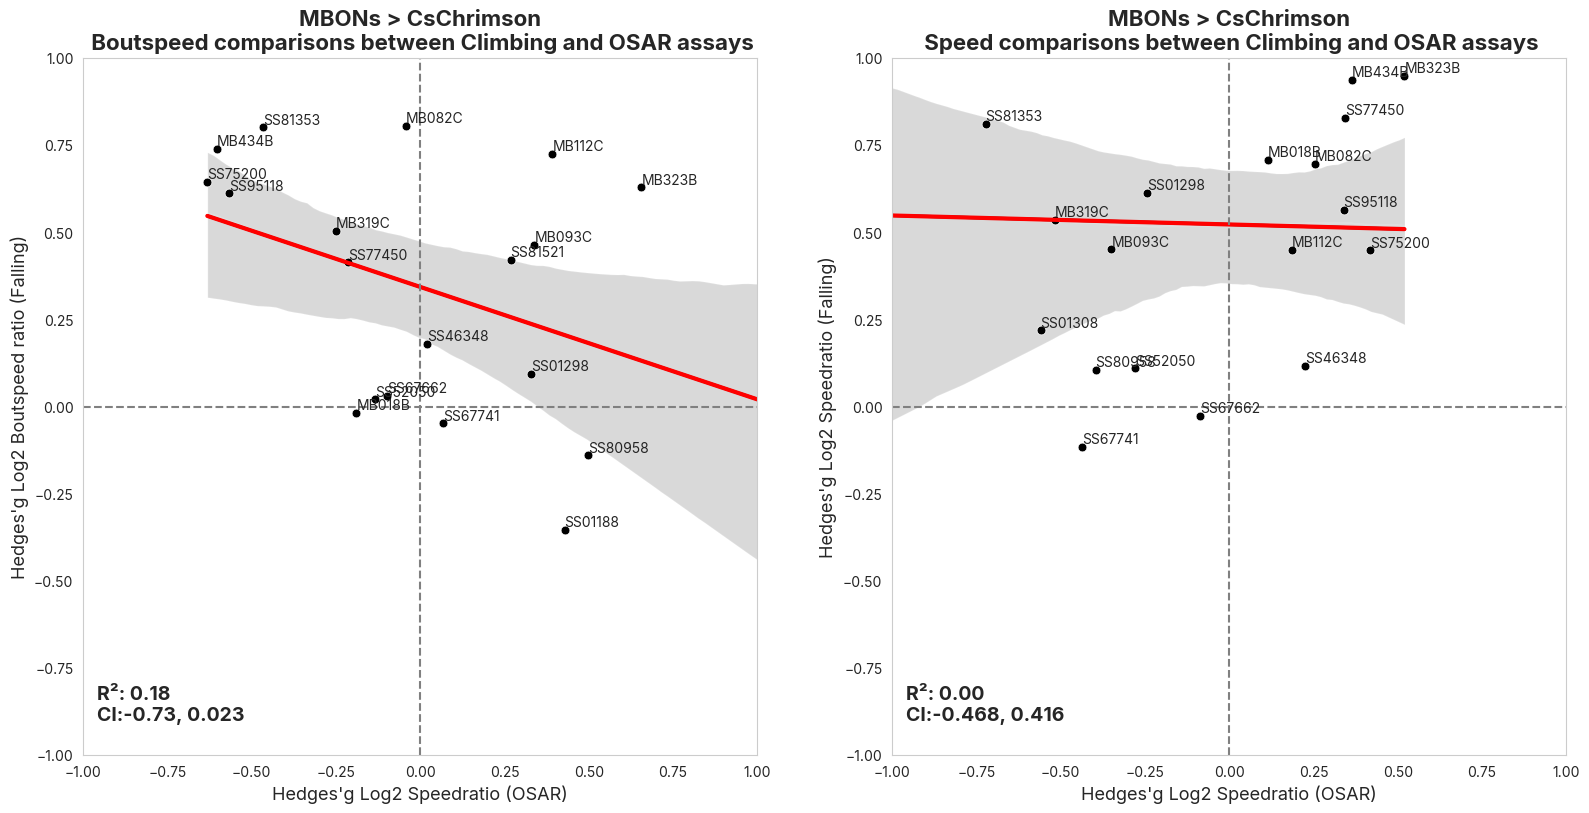

In [16]:
#only for values above magnitude of 0.2 and no VT999036
import scipy.stats

plt.rcParams["font.family"] = "Inter"

figosarplot, axscatter_o = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={"width_ratios":[1,1]})

df02omitteddf = omission(df_specificmbon)

# First subplot
x_label_1 = "Δ Log2 Pace Ratio"
y_label_1 = 'bspeed_hedgesg'

sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_o[0]) #ci color
sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_o[0])  #line color
sns.scatterplot(x=x_label_1, y=y_label_1, data=df02omitteddf, s = 40, color = 'k', ax=axscatter_o[0])

axscatter_o[0].set_xlabel("Hedges'g Log2 Speedratio (OSAR)", fontsize = 13)
axscatter_o[0].set_ylabel("Hedges'g Log2 Boutspeed ratio (Climbing)", fontsize = 13)
axscatter_o[0].grid(False)
axscatter_o[0].set_ylim([-1, 1])
axscatter_o[0].set_xlim([-1, 1])
axscatter_o[0].axvline(0, c=(.5, .5, .5), ls= '--')
axscatter_o[0].axhline(0, c=(.5, .5, .5), ls= '--')
axscatter_o[0].set_title("MBONs > " + responderrename + "\n Boutspeed comparisons between Climbing and OSAR assays", weight = "bold", fontfamily = "Inter", fontsize = 16)
axscatter_o[0].yaxis.set_tick_params(labelbottom=True)

for n, k in enumerate(df02omitteddf['MBON']):
    axscatter_o[0].annotate(k, (df02omitteddf.loc[n,x_label_1], df02omitteddf.loc[n,y_label_1]+0.01), fontsize = 10)

#correlation for first subplot
pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(df02omitteddf[x_label_1], df02omitteddf[y_label_1]) #correlation instead of linear regression: trying to find the relationship rather than causation    
civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
axscatter_o[0].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), (0.02, 0.05), 
                        ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 14)


# Second subplot
x_label_2 = "Δ Log2 Speed Ratio"
y_label_2 = 'speed_hedgesg'

sns.regplot(x=x_label_2, y=y_label_2, data=df02omitteddf, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_o[1]) #ci color
sns.regplot(x=x_label_2, y=y_label_2, data=df02omitteddf, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_o[1]) #linecolor
sns.scatterplot(x=x_label_2, y=y_label_2, data=df02omitteddf, s = 40, color = 'k', ax=axscatter_o[1])

axscatter_o[1].set_xlabel("Hedges'g Log2 Speedratio (OSAR)", fontsize = 13)
axscatter_o[1].set_ylabel("Hedges'g Log2 Speedratio (Climbing)", fontsize = 13)
axscatter_o[1].grid(False)
axscatter_o[1].set_ylim([-1, 1])
axscatter_o[1].set_xlim([-1, 1])
axscatter_o[1].axvline(0, c=(.5, .5, .5), ls= '--')
axscatter_o[1].axhline(0, c=(.5, .5, .5), ls= '--')
axscatter_o[1].set_title("MBONs > " + responderrename + "\n Speed comparisons between Climbing and OSAR assays", weight = "bold", fontsize = 16)
axscatter_o[1].yaxis.set_tick_params(labelbottom=True)

for n, k in enumerate(df02omitteddf['MBON']):
    axscatter_o[1].annotate(k, (df02omitteddf.loc[n,x_label_2], df02omitteddf.loc[n,y_label_2]+0.01), fontsize = 10)

#correlation for second subplot
pearsonscorrelation_cr2_2 = scipy.stats.pearsonr(df02omitteddf[x_label_2], df02omitteddf[y_label_2]) #correlation instead of linear regression: trying to find the relationship rather than causation    
civallow_cr2_2 = pearsonscorrelation_cr2_2.confidence_interval(confidence_level=0.95)[0] 
civalhigh_cr2_2 = pearsonscorrelation_cr2_2.confidence_interval(confidence_level=0.95)[1]  
axscatter_o[1].annotate(f"R²: {(round(pearsonscorrelation_cr2_2[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_2,3)) + ", " + str(round(civalhigh_cr2_2,3)), (0.02, 0.05), 
                        ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 14)

plt.tight_layout()
plt.subplots_adjust(top = 0.95, wspace=0.2)

plt.savefig(filesavedir + date + "_" + responder + "_linreg.png", dpi = 1200, bbox_inches='tight')
plt.savefig(filesavedir + date + "_" + responder + "_linreg.svg")

## Clustering

weighted euclidean


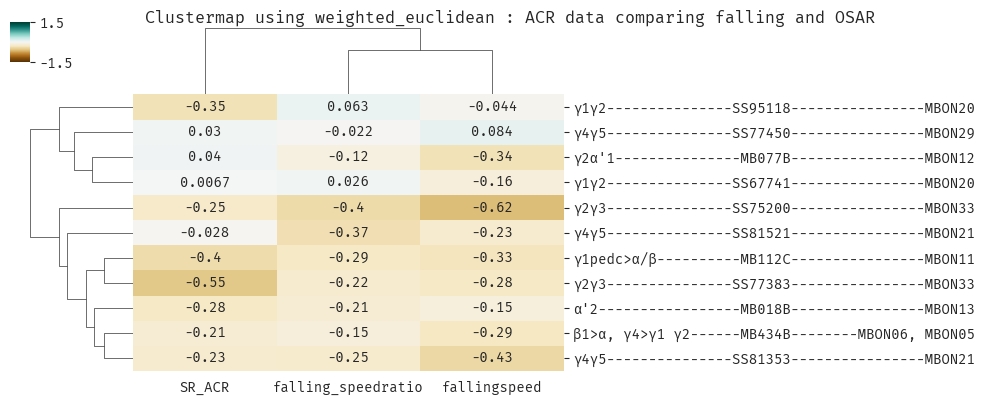

In [ ]:
methodlist = ['weighted']
metriclist = ['euclidean']
       
df601 = df600.copy()
df601['totalnaming'] = df601['MBON'] + "; " + df601['Name'] + "; " + df601['Lobe']
df601newset = df601.set_index('totalnaming').filter(items = ["climbing_speedratio", "climbingspeed", "SR_ACR"])
plt.rcParams["font.family"] = "Inter"

ylabellist = []
for n, k, z in zip(df601['MBON'],df601['Lobe'], df601['Name']):
    ylabels = f"{k:-<18}{n:-^10}{z:->20}"
    ylabellist.append(ylabels)

for methodd in methodlist:
    for metricc in metriclist:
        print (methodd + " " + metricc)
        j7 = sns.clustermap(df601newset, cmap='BrBG', metric = metricc, method = methodd, yticklabels=ylabellist, vmin = -1.5, vmax=1.5, annot=True,
                            cbar_kws = dict(shrink = 0.15, ticks = [-1.5,1.5]), figsize=(10, 4), cbar_pos=(0, 0.87, .02, .1) ) #use_gridspec=False,location="bottom", shrink = 0.25, pad=0.01 #vmin = -1.5, vmax=1.5,
        ax = j7.ax_heatmap
        ax.set_ylabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 0, fontsize = 10)
        wrap_labels(ax, 8)
        j7.fig.suptitle('Clustermap using ' + methodd + "_" + metricc + ' : ACR data comparing climbing and OSAR' , weight='bold', fontsize =12, y =1.0)

        #plt.rcParams["font.family"] = "Inter"
        #plt.savefig(openPath + "images\\" + date + "_" + responder + "_clustermap_" + methodd + "_" + metricc + "_betweenChrimsonandACR.png", dpi = 1200)

In [ ]:
import scipy.stats

dflin = dfreg_ao.copy()
fig2, ax2 = plt.subplots(nrows = 1, ncols = 9, figsize = (20, 3), sharey = True, layout= 'constrained')
labels = dflin['MBON']

for c,(n,leg) in enumerate(zip(dfreg_a.columns[:-2].tolist(),8*[False]+[True])):
    spare = pd.DataFrame()
    spare["ACR"] = matchinglobesets(dfreg_a, lobelocation)[n]
    spare['Chrimson2'] = matchinglobesets(dfreg_c, lobelocation)[n]
    spare['NT'] = matchinglobesets(dfreg_c, lobelocation)['Neurotransmitter']
    sns.regplot(x="ACR", y="Chrimson2", data=spare, ci = 95, scatter = False, line_kws={"color": "black", 'lw': 1.5}, ax=ax2[c]) 
    sns.scatterplot(x="ACR", y="Chrimson2", data=spare, hue='NT', s = 3, ax = ax2[c], legend = leg)
    ax2[c].set_xlim([-2,2])
    ax2[c].set_ylim([-2,2])
    ax2[c].set_xlabel(labels[c])
    ax2[c].set_ylabel("")
    
    #pearsons correlation
    pearsonscorrelation = scipy.stats.pearsonr(dfreg_a[n], dfreg_c[n]) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow = pearsonscorrelation.confidence_interval(confidence_level=0.95)[0] 
    civalhigh = pearsonscorrelation.confidence_interval(confidence_level=0.95)[1]   
    ax2[c].annotate("Coeff:" + str(round(pearsonscorrelation[0],3)) + "\nCI:" + str(round(civallow,3)) + ", " + str(round(civalhigh,3)), (0.45, 0.8), ha = "left", xycoords = 'axes fraction', fontsize = 8)

fig2.supxlabel("ACR", weight = "bold")
fig2.supylabel("Chrimson2", weight = "bold")
fig2.suptitle("Linear regression with Pearson's coeff", fontsize = 16, weight="bold")

new_labels = ['Glutamate', 'Acetylcholine', 'GABA', 'Acetylcholine, GABA']
legend_handles, _= ax2[c].get_legend_handles_labels()
lgd = fig2.legend(legend_handles, new_labels, 
          bbox_to_anchor=(1,1), ncol = 4, frameon = False)
ax2[c].get_legend().set_visible(False)

#plt.savefig(openPath + "images\\" + date + "_" + responder + "_bidirectionalitycheck.png", dpi = 1200, bbox_inches='tight')